<a href="https://colab.research.google.com/github/Srilahari9826/TASK-Python-pgm/blob/main/Feature_Engineering_Modules.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Feature Engineering - Introduction

## 1) What is Feature Engineering?

Feature Engineering is the process of transforming raw data into useful features that help machine learning models perform better.

* We convert data into a form that machines can understand easily.

---

## 2) Why is Feature Engineering Important?
- Improves model accuracy
- Helps in better data understanding
- Removes noise and unnecessary information
- Makes patterns more visible

---

##  Types of Features

### 1. Numerical Features
- Continuous values
- Example:Annual income, Test score, Latitude,Number of items purchased

### 2. Categorical Features
- Labels or categories
- Example: country of residence, Customer Subscription plan, payment method,Eye color

### 3. Text Features
- Words or sentences
- Example:Search Queries, book Titles, Social media Comments

### 4. Date-Time Features
- Time-based data
- Example:Last login time, Holiday Flag, Expiration Date

---

##  Goal of Feature Engineering
Convert raw data into meaningful inputs for ML models

In [11]:
import pandas as pd
import numpy as np

# Sample dataset
data = {
    "Name": ["Abhi", "rugved", "Charry"],
    "Age": [18, 20, 35],
    "Gender": ["Male", "Male", "female"],
    "Salary": [70000, 80000, 60000],
    "Joining_Date": ["2022-01-01", "2021-06-15", "2020-03-20"]
}

df = pd.DataFrame(data)
df.head()

,Name,Age,Gender,Salary,Joining_Date
0,Abhi,18,Male,70000,2022-01-01
1,rugved,20,Male,80000,2021-06-15
2,Charry,35,female,60000,2020-03-20


In [12]:
df.dtypes

,0
Name,object
Age,int64
Gender,object
Salary,int64
Joining_Date,object


Age & Salary → Numerical Features

Gender → Categorical Feature

Name → Text Feature

Joining_Date → Date-Time Feature

 Handling Numerical Data

1) What is Numerical Data?

Numerical data consists of numbers and can be measured.

👉 Examples:

Age

Salary

Temperature

2) Why do we need to process numerical data?

Different features may have different scales
Large values can dominate smaller ones
Models perform better when data is properly scaled

 1. Feature Scaling

* Standardization
Converts data to mean = 0 and standard deviation = 1

* Normalization (Min-Max Scaling)

Scales values between 0 and 1

 2. Log Transformation

Used to reduce skewness in data

Helps in handling large values

 3. Binning (Discretization)

Converts continuous values into categories

Example: Age → Young, Adult, Old

Feature Scaling – Standardization

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_scaled = df.copy()
df_scaled[["Age", "Salary"]] = scaler.fit_transform(df[["Age", "Salary"]])

df_scaled

,Name,Age,Gender,Salary,Joining_Date
0,Abhi,-0.834812,Male,0.000000,2022-01-01
1,rugved,-0.571187,Male,1.224745,2021-06-15
2,Charry,1.405999,female,-1.224745,2020-03-20


Feature Scaling – Normalization (Min-Max)

In [14]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df_normalized = df.copy()
df_normalized[["Age", "Salary"]] = scaler.fit_transform(df[["Age", "Salary"]])

df_normalized

,Name,Age,Gender,Salary,Joining_Date
0,Abhi,0.000000,Male,0.5,2022-01-01
1,rugved,0.117647,Male,1.0,2021-06-15
2,Charry,1.000000,female,0.0,2020-03-20


Log Transformation

In [16]:
df_log = df.copy()

df["Log_Salary"] = np.log(df["Salary"])
df_log

,Name,Age,Gender,Salary,Joining_Date,Log_Salary
0,Abhi,18,Male,70000,2022-01-01,11.156251
1,rugved,20,Male,80000,2021-06-15,11.289782
2,Charry,35,female,60000,2020-03-20,11.002100


Binning (Discretization)

In [17]:
bins = [0, 20, 40, 100]
labels = ["Young", "Adult", "Senior"]

df["Age_Group"] = pd.cut(df["Age"], bins=bins, labels=labels)

df

,Name,Age,Gender,Salary,Joining_Date,Log_Salary,Age_Group
0,Abhi,18,Male,70000,2022-01-01,11.156251,Young
1,rugved,20,Male,80000,2021-06-15,11.289782,Young
2,Charry,35,female,60000,2020-03-20,11.002100,Adult


- Standardization → Used in algorithms like Logistic Regression, SVM
- Normalization → Used in Neural Networks
- Log Transform → Reduces skewed data
- Binning → Converts numbers into categories

Handling Categorical Data

1] What is Categorical Data?

Categorical data represents labels or categories.

Examples:

Gender (Male/Female)

City (Mumbai, Delhi, Pune)

Color (Red, Blue, Green)

2] Why convert categorical data?

Machine Learning models work with numbers, not text.

 So we convert categories ➝ numerical form

3] Encoding Techniques

1. Label Encoding
Converts categories into numbers

Example: Male → 0, Female → 1

2. One-Hot Encoding

Creates separate columns for each category

Uses 0 and 1

3. Ordinal Encoding

Used when categories have order

Example: Low < Medium < High

4. Frequency Encoding

Replace category with its frequency

5. Target Encoding (Basic Idea)

Replace category with mean of target variable

In [20]:
import pandas as pd

data = {
    "Name": ["A", "B", "C", "D", "E","F"],
    "Gender": ["Abhi", "yshu", "Female", "Male", "kitty","Other"],
    "City": ["Mumbai", "Delhi", "Mumbai", "Pune", "Delhi","Delhi"],
    "Performance": ["Low", "Medium", "High", "Medium", "Low","High"]
}

df = pd.DataFrame(data)
df

,Name,Gender,City,Performance
0,A,Abhi,Mumbai,Low
1,B,yshu,Delhi,Medium
2,C,Female,Mumbai,High
3,D,Male,Pune,Medium
4,E,kitty,Delhi,Low
5,F,Other,Delhi,High


Label Encoding

In [21]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["Gender_Label"] = le.fit_transform(df["Gender"])
df["City_Label"] = le.fit_transform(df["City"])
df

,Name,Gender,City,Performance,Gender_Label,City_Label
0,A,Abhi,Mumbai,Low,0,1
1,B,yshu,Delhi,Medium,5,0
2,C,Female,Mumbai,High,1,1
3,D,Male,Pune,Medium,2,2
4,E,kitty,Delhi,Low,4,0
5,F,Other,Delhi,High,3,0


one_Hot Encoding

In [29]:
data = {
    "Color": ["Red", "Blue", "Green", "Red", "Blue"]
}

df = pd.DataFrame(data)
df = pd.get_dummies(df, columns=["Color"])
df

,Color_Blue,Color_Green,Color_Red
0,False,False,True
1,True,False,False
2,False,True,False
3,False,False,True
4,True,False,False


Ordinal Encoding

In [22]:
order = {"Low": 3, "Medium": 2, "High": 1}

df["Performance_Ordinal"] = df["Performance"].map(order)
df

,Name,Gender,City,Performance,Gender_Label,City_Label,Performance_Ordinal
0,A,Abhi,Mumbai,Low,0,1,3
1,B,yshu,Delhi,Medium,5,0,2
2,C,Female,Mumbai,High,1,1,1
3,D,Male,Pune,Medium,2,2,2
4,E,kitty,Delhi,Low,4,0,3
5,F,Other,Delhi,High,3,0,1


Frequency Encoding

In [23]:
freq = df["City"].value_counts()

df["City_Freq"] = df["City"].map(freq)
df

,Name,Gender,City,Performance,Gender_Label,City_Label,Performance_Ordinal,City_Freq
0,A,Abhi,Mumbai,Low,0,1,3,2
1,B,yshu,Delhi,Medium,5,0,2,3
2,C,Female,Mumbai,High,1,1,1,2
3,D,Male,Pune,Medium,2,2,2,1
4,E,kitty,Delhi,Low,4,0,3,3
5,F,Other,Delhi,High,3,0,1,3


Target Encoding

In [27]:
df["Target"] = [0, 1, 1, 0, 1,2]

# Calculate mean target per category
target_mean = df.groupby("City")["Target"].mean()

df["City_Target_Encoded"] = df["City"].map(target_mean)
df

,Name,Gender,City,Performance,Gender_Label,City_Label,Performance_Ordinal,City_Freq,Target,City_Target_Encoded
0,A,Abhi,Mumbai,Low,0,1,3,2,0,0.500000
1,B,yshu,Delhi,Medium,5,0,2,3,1,1.333333
2,C,Female,Mumbai,High,1,1,1,2,1,0.500000
3,D,Male,Pune,Medium,2,2,2,1,0,0.000000
4,E,kitty,Delhi,Low,4,0,3,3,1,1.333333
5,F,Other,Delhi,High,3,0,1,3,2,1.333333


- Label Encoding → Simple, but not good for unordered data
- One-Hot Encoding → Most commonly used
- Ordinal Encoding → Use when order exists
- Frequency Encoding → Useful for high-cardinality data
- Target Encoding → Advanced, used in competitions

#  Handling Date & Time Features

## 1) What is Date-Time Data?
Date-Time data represents time-related information.

  Examples:
- Joining Date
- Timestamp
- Order Date

---

## 2) Why use Date-Time Features?
- Helps in finding patterns over time
- Useful in trends, seasonality, and time-based predictions

---

##  Common Feature Extraction

###  Extract from Date:
- Year
- Month
- Day
- Weekday

---

###  Time-Based Features:
- Hour
- Minute
- Second

---

###  Cyclical Encoding (Basic Idea)
- Some features repeat (like months, days)
- Example:
  December (12) is close to January (1)
- Use Sin & Cos transformation to preserve this pattern

In [30]:
import pandas as pd

data = {
    "Name": ["A", "B", "C"],
    "Joining_Date": ["2022-01-15", "2021-06-20", "2020-12-05"]
}

df = pd.DataFrame(data)

# Convert to datetime
df["Joining_Date"] = pd.to_datetime(df["Joining_Date"])

df

,Name,Joining_Date
0,A,2022-01-15
1,B,2021-06-20
2,C,2020-12-05


 Extract Date Features

In [31]:
df["Year"] = df["Joining_Date"].dt.year
df["Month"] = df["Joining_Date"].dt.month
df["Day"] = df["Joining_Date"].dt.day
df["Weekday"] = df["Joining_Date"].dt.day_name()

df

,Name,Joining_Date,Year,Month,Day,Weekday
0,A,2022-01-15,2022,1,15,Saturday
1,B,2021-06-20,2021,6,20,Sunday
2,C,2020-12-05,2020,12,5,Saturday


Extract Time  Features

In [32]:
df["Full_DateTime"] = pd.to_datetime([
    "2022-01-15 10:30:00",
    "2021-06-20 14:45:00",
    "2020-12-05 08:15:00"
])

df["Hour"] = df["Full_DateTime"].dt.hour
df["Minute"] = df["Full_DateTime"].dt.minute

df

,Name,Joining_Date,Year,Month,Day,Weekday,Full_DateTime,Hour,Minute
0,A,2022-01-15,2022,1,15,Saturday,2022-01-15 10:30:00,10,30
1,B,2021-06-20,2021,6,20,Sunday,2021-06-20 14:45:00,14,45
2,C,2020-12-05,2020,12,5,Saturday,2020-12-05 08:15:00,8,15


Cyclical Encoding

In [33]:
import numpy as np

# Apply on Month
df["Month_sin"] = np.sin(2 * np.pi * df["Month"] / 12)
df["Month_cos"] = np.cos(2 * np.pi * df["Month"] / 12)

df

,Name,Joining_Date,Year,Month,Day,Weekday,Full_DateTime,Hour,Minute,Month_sin,Month_cos
0,A,2022-01-15,2022,1,15,Saturday,2022-01-15 10:30:00,10,30,5.000000e-01,0.866025
1,B,2021-06-20,2021,6,20,Sunday,2021-06-20 14:45:00,14,45,1.224647e-16,-1.000000
2,C,2020-12-05,2020,12,5,Saturday,2020-12-05 08:15:00,8,15,-2.449294e-16,1.000000


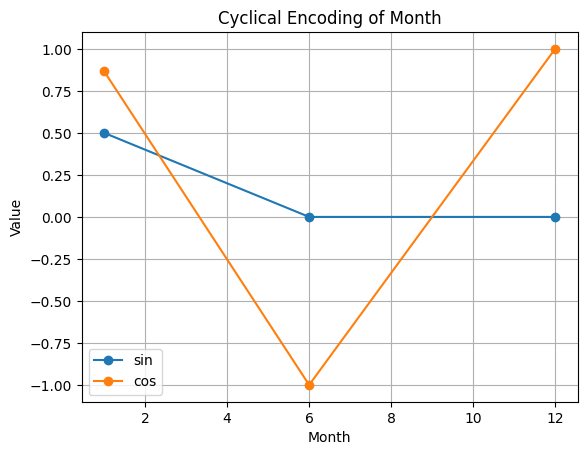

In [34]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(df["Month"], df["Month_sin"], marker='o', label="sin")
plt.plot(df["Month"], df["Month_cos"], marker='o', label="cos")

plt.xlabel("Month")
plt.ylabel("Value")
plt.title("Cyclical Encoding of Month")
plt.legend()
plt.grid()

plt.show()

- Extracting features helps model understand time patterns
- Weekday helps identify behavior (e.g., weekends vs weekdays)
- Cyclical encoding preserves circular nature of time

#  Feature Creation

## 1) What is Feature Creation?
Feature Creation means creating new features from existing data to improve model performance.

 In simple terms:
We make new useful columns from old ones.

---

## 2) Why is it important?
- Helps model learn better patterns
- Adds more meaningful information
- Improves accuracy

---

##  Types of Feature Creation

###  1. Mathematical Transformations
- Addition, subtraction, multiplication
- Example: Total = Price × Quantity

---

###  2. Combining Features
- Merge two columns into one
- Example: First Name + Last Name

---

###  3. Extracting Information
- From text or existing columns
- Example: Email → Domain

---

###  4. Domain-Based Features (Basic Idea)
- Based on real-world knowledge
- Example: BMI = Weight / Height²

In [37]:
import pandas as pd

data = {
    "Name": ["A", "B", "C"],
    "Price": [100, 200, 150],
    "Quantity": [2, 3, 5],
    "First_Name": ["sree", "sai", "Sam"],
    "Last_Name": ["puppy", "Snopy", "Brown"],
    "Email": ["sree@gmail.com", "sai@yahoo.com", "sam@outlook.com"]
}

df = pd.DataFrame(data)
df

,Name,Price,Quantity,First_Name,Last_Name,Email
0,A,100,2,sree,puppy,sree@gmail.com
1,B,200,3,sai,Snopy,sai@yahoo.com
2,C,150,5,Sam,Brown,sam@outlook.com


Mathematical Feature Creation

In [38]:
df["Total_Price"] = df["Price"] * df["Quantity"]

df

,Name,Price,Quantity,First_Name,Last_Name,Email,Total_Price
0,A,100,2,sree,puppy,sree@gmail.com,200
1,B,200,3,sai,Snopy,sai@yahoo.com,600
2,C,150,5,Sam,Brown,sam@outlook.com,750


Combining Features

In [39]:
df["Full_Name"] = df["First_Name"] + " " + df["Last_Name"]

df

,Name,Price,Quantity,First_Name,Last_Name,Email,Total_Price,Full_Name
0,A,100,2,sree,puppy,sree@gmail.com,200,sree puppy
1,B,200,3,sai,Snopy,sai@yahoo.com,600,sai Snopy
2,C,150,5,Sam,Brown,sam@outlook.com,750,Sam Brown


Extracting Information

In [40]:
df["Email_Domain"] = df["Email"].apply(lambda x: x.split("@")[1])

df

,Name,Price,Quantity,First_Name,Last_Name,Email,Total_Price,Full_Name,Email_Domain
0,A,100,2,sree,puppy,sree@gmail.com,200,sree puppy,gmail.com
1,B,200,3,sai,Snopy,sai@yahoo.com,600,sai Snopy,yahoo.com
2,C,150,5,Sam,Brown,sam@outlook.com,750,Sam Brown,outlook.com


Domain-Based Feature

In [41]:
df["Weight"] = [60, 70, 80]   # kg
df["Height"] = [1.6, 1.7, 1.8]  # meters

# BMI Formula
df["BMI"] = df["Weight"] / (df["Height"] ** 2)

df

,Name,Price,Quantity,First_Name,Last_Name,Email,Total_Price,Full_Name,Email_Domain,Weight,Height,BMI
0,A,100,2,sree,puppy,sree@gmail.com,200,sree puppy,gmail.com,60,1.6,23.437500
1,B,200,3,sai,Snopy,sai@yahoo.com,600,sai Snopy,yahoo.com,70,1.7,24.221453
2,C,150,5,Sam,Brown,sam@outlook.com,750,Sam Brown,outlook.com,80,1.8,24.691358


- Feature creation adds new useful information
- Total_Price helps understand spending
- Full_Name combines identity info
- Email domain can show user type
- BMI is a real-world meaningful feature

#  Handling Missing Values

##1) What are Missing Values?
Missing values are empty or null data in a dataset.

 Examples:
- NaN
- None
- Blank cells

---

## 2) Why handle missing values?
- ML models cannot handle missing data
- Can reduce accuracy
- May cause errors in computation

---

## 3) Common Techniques

###  1. Mean Imputation
- Replace missing values with average

---

###  2. Median Imputation
- Replace with middle value
- Useful for skewed data

---

###  3. Mode Imputation
- Replace with most frequent value

---

###  4. Forward Fill
- Fill using previous value

---

###  5. Backward Fill
- Fill using next value

---

###  6. Missing Indicator
- Create a column to mark missing values

In [42]:
import pandas as pd
import numpy as np

data = {
    "Age": [25, np.nan, 30, 35, np.nan],
    "Salary": [50000, 60000, np.nan, 80000, 90000],
    "City": ["Mumbai", "Delhi", None, "Pune", "Delhi"]
}

df = pd.DataFrame(data)
df

,Age,Salary,City
0,25.0,50000.0,Mumbai
1,NaN,60000.0,Delhi
2,30.0,NaN,None
3,35.0,80000.0,Pune
4,NaN,90000.0,Delhi


Check Missing values

In [43]:
df.isnull().sum()

,0
Age,2
Salary,1
City,1


Mean Imputation

In [46]:
df2 = df.copy()
df2["Age"].fillna(df2["Age"].mean(), inplace=True)

df2

/tmp/ipykernel_16460/1096490385.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df2["Age"].fillna(df2["Age"].mean(), inplace=True)


,Age,Salary,City
0,25.0,50000.0,Mumbai
1,30.0,60000.0,Delhi
2,30.0,NaN,None
3,35.0,80000.0,Pune
4,30.0,90000.0,Delhi


Median Imputation

In [47]:
df2 = df.copy()
df2["Salary"].fillna(df2["Salary"].median(), inplace=True)

df2

/tmp/ipykernel_16460/2046029052.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df2["Salary"].fillna(df2["Salary"].median(), inplace=True)


,Age,Salary,City
0,25.0,50000.0,Mumbai
1,NaN,60000.0,Delhi
2,30.0,70000.0,None
3,35.0,80000.0,Pune
4,NaN,90000.0,Delhi


Mode Imputation

In [48]:
df2 = df.copy()
df2["City"].fillna(df2["City"].mode()[0], inplace=True)

df2

/tmp/ipykernel_16460/3096974920.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df2["City"].fillna(df2["City"].mode()[0], inplace=True)


,Age,Salary,City
0,25.0,50000.0,Mumbai
1,NaN,60000.0,Delhi
2,30.0,NaN,Delhi
3,35.0,80000.0,Pune
4,NaN,90000.0,Delhi


Forward Fill

In [49]:
df_ffill = df.fillna(method="ffill")
df_ffill

/tmp/ipykernel_16460/1246910402.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_ffill = df.fillna(method="ffill")


,Age,Salary,City
0,25.0,50000.0,Mumbai
1,25.0,60000.0,Delhi
2,30.0,60000.0,Delhi
3,35.0,80000.0,Pune
4,35.0,90000.0,Delhi


Backward Fill

In [50]:
df_bfill = df.fillna(method="bfill")
df_bfill

/tmp/ipykernel_16460/1714158225.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_bfill = df.fillna(method="bfill")


,Age,Salary,City
0,25.0,50000.0,Mumbai
1,30.0,60000.0,Delhi
2,30.0,80000.0,Pune
3,35.0,80000.0,Pune
4,NaN,90000.0,Delhi


Missing Indicator

In [51]:
df["Age_missing"] = df["Age"].isnull().astype(int)

df

,Age,Salary,City,Age_missing
0,25.0,50000.0,Mumbai,0
1,NaN,60000.0,Delhi,1
2,30.0,NaN,None,0
3,35.0,80000.0,Pune,0
4,NaN,90000.0,Delhi,1


- Mean → Good for normal data
- Median → Best for skewed data
- Mode → Used for categorical data
- Forward/Backward Fill → Useful in time series
- Missing Indicator → Helps model know missing patterns

#  Feature Selection

## 1) What is Feature Selection?
Feature Selection means selecting the most important features for the model and removing unnecessary ones.

 In simple terms:
Keep useful columns, remove useless ones.

---

## 2) Why is it important?
- Reduces complexity
- Improves model performance
- Reduces overfitting
- Faster training

---

##  Types of Feature Selection

###  1. Filter Methods
- Based on statistical measures
- Example: Correlation

---

###  2. Wrapper Methods (Basic Idea)
- Try different combinations of features
- Select best performing set

---

###  3. Embedded Methods
- Feature selection happens during model training
- Example: Feature importance

---

In [52]:
import pandas as pd

data = {
    "Age": [25, 30, 35, 40, 45],
    "Salary": [30000, 40000, 50000, 60000, 70000],
    "Experience": [1, 3, 5, 7, 9],
    "Purchased": [0, 0, 1, 1, 1]  # Target variable
}

df = pd.DataFrame(data)
df

,Age,Salary,Experience,Purchased
0,25,30000,1,0
1,30,40000,3,0
2,35,50000,5,1
3,40,60000,7,1
4,45,70000,9,1


Correlation (Filter Method)

In [53]:
df.corr()

,Age,Salary,Experience,Purchased
Age,1.000000,1.000000,1.000000,0.866025
Salary,1.000000,1.000000,1.000000,0.866025
Experience,1.000000,1.000000,1.000000,0.866025
Purchased,0.866025,0.866025,0.866025,1.000000


Select Important Features (based on correlation)

In [54]:
corr_with_target = df.corr()["Purchased"]

corr_with_target

,Purchased
Age,0.866025
Salary,0.866025
Experience,0.866025
Purchased,1.000000


Drop Less Important Features

In [56]:
df_selected = df.drop(columns=["Age"])  # just for demo

df_selected

,Salary,Experience,Purchased
0,30000,1,0
1,40000,3,0
2,50000,5,1
3,60000,7,1
4,70000,9,1


- Correlation shows relationship with target
- Remove features with very low impact
- Feature importance gives real model-based importance
- Helps in better and faster models

#  Handling Outliers

## 1) What are Outliers?
Outliers are data points that are very different from the rest of the data.

 Example:
Most salaries = 30k–50k  
One salary = 5,00,000 → Outlier

---

## 2) Why handle outliers?
- Can distort analysis
- Affects model performance
- Leads to incorrect predictions

---

## 3) Detection Methods

###  1. IQR (Interquartile Range)
- Based on quartiles (Q1, Q3)

---

###  2. Z-Score
- Based on standard deviation

---

###  3. Visualization
- Boxplot
- Scatter plot

---

##  Treatment Methods

- Remove outliers
- Cap values (limit max/min)
- Transform data (log)

In [57]:
import pandas as pd

data = {
    "Salary": [30000, 35000, 40000, 45000, 50000, 1000000]  # Outlier present
}

df = pd.DataFrame(data)
df

,Salary
0,30000
1,35000
2,40000
3,45000
4,50000
5,1000000


Detect Outliers using IQR

In [58]:
Q1 = df["Salary"].quantile(0.25)
Q3 = df["Salary"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

lower_bound, upper_bound

# Detect outliers
outliers = df[(df["Salary"] < lower_bound) | (df["Salary"] > upper_bound)]

print(outliers)

    Salary
5  1000000


Identify Outliers

In [59]:
outliers = df[(df["Salary"] < lower_bound) | (df["Salary"] > upper_bound)]
outliers

,Salary
5,1000000


Remove Outliers

In [60]:
df_no_outliers = df[(df["Salary"] >= lower_bound) & (df["Salary"] <= upper_bound)]
df_no_outliers

,Salary
0,30000
1,35000
2,40000
3,45000
4,50000


Cap Outliers

In [61]:
df_capped = df.copy()

df_capped["Salary"] = df_capped["Salary"].clip(lower_bound, upper_bound)
df_capped

,Salary
0,30000
1,35000
2,40000
3,45000
4,50000
5,67500


Z-Score Method

In [62]:
from scipy import stats

z_scores = stats.zscore(df["Salary"])
z_scores

array([-0.47508713, -0.46111398, -0.44714082, -0.43316767, -0.41919452,
        2.23570412])

Identify Outliers using Z-Score

In [63]:
df_z = df[(abs(z_scores) > 2)]
df_z

,Salary
5,1000000


- IQR → Most common method
- Z-score → Good for normally distributed data
- Removing → When outliers are errors
- Capping → When data is important but extreme